In [1]:
import sys
# на уровень выше из research_rank/
sys.path.insert(0, '..')
from Tomography_qutrit import*
import matplotlib.pyplot as plt

### Попробуем сначала замоделировать смешивания двух состояний и их восстановление

Для начала рассмотрим идеальные случай

In [2]:
protocol = [Gl_4(0), Gl_4(pi / 8), Gl_4(3 * pi / 8), Gl_4(5 * pi / 8), Gl_4(7 * pi / 8)]
tomography = tomography_pol_qutrit(protocol)
rank = 2


sigma1 = 100
sigma2 = 100
sigma3 = 100

teor_state = tomography.density(tomography.hh)
khh = (tomography.B @ teor_state.flatten().reshape(-1, 1)).flatten() 
khh = khh.reshape(-1, len(protocol)).T.flatten()

tomography.experiment(khh, teor_state, sigma1, sigma2, sigma3, rank)

Fidelity between start matrix density and matrix pseudoinversion = 1.0
Finish fidelity = 1.0


In [3]:
protocol = [Gl_4(0), Gl_4(pi / 8), Gl_4(3 * pi / 8), Gl_4(5 * pi / 8), Gl_4(7 * pi / 8)]
tomography = tomography_pol_qutrit(protocol)
rank = 2

sigma1 = 100
sigma2 = 100
sigma3 = 100

teor_state_1 = array(tomography.density(tomography.hh), complex)
teor_state_2 = array(tomography.density(tomography.vv), complex)
prob_1 = 0.35
prob_2 = 1.0 - prob_1

freq_1 = (tomography.B @ teor_state_1.flatten().reshape(-1, 1)).flatten() 
freq_1 = freq_1.reshape(-1, len(protocol)).T.flatten()
freq_2 = (tomography.B @ teor_state_2.flatten().reshape(-1, 1)).flatten() 
freq_2 = freq_2.reshape(-1, len(protocol)).T.flatten()

teor_state = prob_1 * teor_state_1 + prob_2 * teor_state_2
freq = prob_1 * freq_1 + prob_2 * freq_2

tomography.experiment(freq, teor_state, sigma1, sigma2, sigma3, rank)

Fidelity between start matrix density and matrix pseudoinversion = 1.0
Finish fidelity = 1.0000000000000009


In [4]:
protocol = [Gl_4(0), Gl_4(pi / 8), Gl_4(3 * pi / 8), Gl_4(5 * pi / 8), Gl_4(7 * pi / 8)]
tomography = tomography_pol_qutrit(protocol)
rank = 2

sigma1 = 20
sigma2 = 400
sigma3 = 700

teor_state_1 = array(tomography.density(tomography.hh), complex)
teor_state_2 = array(tomography.density(tomography.vv), complex)
prob_1 = 0.35
prob_2 = 1.0 - prob_1

freq_1 = (tomography.B @ teor_state_1.flatten().reshape(-1, 1)).flatten() 
freq_1 = freq_1.reshape(-1, len(protocol)).T.flatten()
freq_2 = (tomography.B @ teor_state_2.flatten().reshape(-1, 1)).flatten() 
freq_2 = freq_2.reshape(-1, len(protocol)).T.flatten()

teor_state = prob_1 * teor_state_1 + prob_2 * teor_state_2
freq = prob_1 * freq_1 + prob_2 * freq_2
freq[::3] = freq[::3] * sigma1
freq[1::3] = freq[1::3] * sigma2
freq[2::3] = freq[2::3] * sigma3

tomography.experiment(freq, teor_state, sigma1, sigma2, sigma3, rank)

Fidelity between start matrix density and matrix pseudoinversion = 0.9999999999999993
Finish fidelity = 0.9999999999999996


In [5]:
protocol = [Gl_4(0), Gl_4(pi / 8), Gl_4(3 * pi / 8), Gl_4(5 * pi / 8), Gl_4(7 * pi / 8)]
tomography = tomography_pol_qutrit(protocol)
rank = 2

sigma1_1 = 20
sigma2_1 = 400
sigma3_1 = 700

sigma1_2 = 200
sigma2_2 = 1000
sigma3_2 = 70

teor_state_1 = array(tomography.density(tomography.hh), complex)
teor_state_2 = array(tomography.density(tomography.vv), complex)
prob_1 = 0.35
prob_2 = 1.0 - prob_1

freq_1 = (tomography.B @ teor_state_1.flatten().reshape(-1, 1)).flatten() 
freq_1 = freq_1.reshape(-1, len(protocol)).T.flatten()
freq_2 = (tomography.B @ teor_state_2.flatten().reshape(-1, 1)).flatten() 
freq_2 = freq_2.reshape(-1, len(protocol)).T.flatten()

teor_state = prob_1 * teor_state_1 + prob_2 * teor_state_2
freq = prob_1 * freq_1 + prob_2 * freq_2
sigma1 = prob_1 * sigma1_1 + prob_2 * sigma1_2
sigma2 = prob_1 * sigma2_1 + prob_2 * sigma2_2
sigma3 = prob_1 * sigma3_1 + prob_2 * sigma3_2
freq[::3] = freq[::3] * sigma1
freq[1::3] = freq[1::3] * sigma2
freq[2::3] = freq[2::3] * sigma3

tomography.experiment(freq, teor_state, sigma1, sigma2, sigma3, rank)

Fidelity between start matrix density and matrix pseudoinversion = 1.0
Finish fidelity = 1.0


Сделаем моделирование эксперимента

In [6]:
from numpy import random, real, isclose, clip

def probs_to_freqs(probs, N, ignore=False):
    """
    Превращает вероятности в экспериментальные частоты
    через моделирование конечной статистики.
    
    Args:
        probs (array-like): список вероятностей (сумма ≈ 1)
        N (int): общее число экспериментов (например, фотонов)
        ignore (bool): если True, то при сумме != 1 нормирует probs автоматически
    
    Returns:
        freqs (np.ndarray): массив частот (сумма ≈ 1)
        counts (np.ndarray): массив целых отсчётов
    """
    p = array(probs, dtype=float)
    
    # фиксим численные ошибки
    if ignore or not isclose(p.sum(), 1.0):
        if p.sum() <= 0:
            raise ValueError("Сумма вероятностей должна быть > 0")
        p = clip(p, 0, None)   # убираем отрицательные из-за численных артефактов
        p = p / p.sum()
    
    # моделируем эксперимент (мультиномиальное распределение)
    counts = random.multinomial(N, p)
    freqs = counts / N
    
    return freqs

protocol = [Gl_4(0), Gl_4(pi / 8), Gl_4(3 * pi / 8), Gl_4(5 * pi / 8), Gl_4(7 * pi / 8)]
tomography = tomography_pol_qutrit(protocol)
rank = 2
N = 10000

sigma1_1 = 20
sigma2_1 = 400
sigma3_1 = 700

sigma1_2 = 200
sigma2_2 = 1000
sigma3_2 = 70

teor_state_1 = array(tomography.density(tomography.hh), complex)
teor_state_2 = array(tomography.density(tomography.vv), complex)
prob_1 = 0.37
prob_2 = 1.0 - prob_1

freq_1 = (tomography.B @ teor_state_1.flatten().reshape(-1, 1)).flatten() 
freq_1 = freq_1.reshape(-1, len(protocol)).T.flatten()
for i in range(len(protocol)):
    freq_1[3 * i : 3 * (i + 1)] = probs_to_freqs(real(freq_1[3 * i : 3 * (i + 1)]), N)
freq_2 = (tomography.B @ teor_state_2.flatten().reshape(-1, 1)).flatten() 
freq_2 = freq_2.reshape(-1, len(protocol)).T.flatten()
for i in range(len(protocol)):
    freq_2[3 * i : 3 * (i + 1)] = probs_to_freqs(real(freq_2[3 * i : 3 * (i + 1)]), N)

teor_state = prob_1 * teor_state_1 + prob_2 * teor_state_2
freq = prob_1 * freq_1 + prob_2 * freq_2
sigma1 = prob_1 * sigma1_1 + prob_2 * sigma1_2
sigma2 = prob_1 * sigma2_1 + prob_2 * sigma2_2
sigma3 = prob_1 * sigma3_1 + prob_2 * sigma3_2
freq[::3] = freq[::3] * sigma1
freq[1::3] = freq[1::3] * sigma2
freq[2::3] = freq[2::3] * sigma3



tomography.experiment(freq, teor_state, sigma1, sigma2, sigma3, rank)

Fidelity between start matrix density and matrix pseudoinversion = 0.999919288621324
Finish fidelity = 0.9999647731891778


Теперь перейдём к реальным экспериментальным данным



 prob_1 * HH + prob_2 * VV  



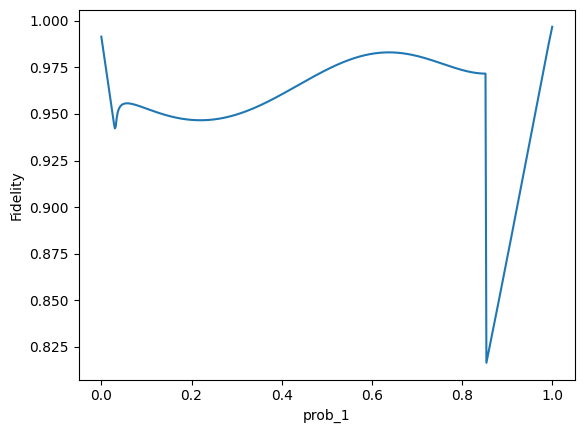

In [7]:
from numpy import linspace
protocol = [Gl_4(0), Gl_4(pi / 8), Gl_4(3 * pi / 8), Gl_4(5 * pi / 8), Gl_4(7 * pi / 8)]
tomography = tomography_pol_qutrit(protocol)
rank = 2


print("\n\n prob_1 * HH + prob_2 * VV  \n")
# # 20 повторения по 10с при HWP_p под 0
# Noise
# 1.2 3.15 233.6
# 72.7 5.35 1.15
# Калибровка      10.7 100.1 69.15
n_hh = 1.2 / 233.6
n_hv_1 = 3.15 / 233.6
n_hv_2 = 5.35 / 72.7
n_vv = 1.15 / 72.7

sigma1_1 = 10.7 - 69.15 * n_hh
sigma2_1 = (100.1 - 10.7 * n_hv_1 - 69.15 * n_hv_2)/2
sigma3_1 = 69.15 - 10.7 * n_vv

teor_state_1 = tomography.density(tomography.hh)

freq_1 = array([
72.7 - 1.15 * n_hh, 5.35 - 5.35,	1.15 - 72. * n_vv,
44.6 - 20.95 * n_hh, 58.1 - 44.6 * n_hv_1 - 20.95 * n_hv_2, 20.95 - 44.6 * n_vv,
34.55 - 12.95 * n_hh, 94.55 - 34.55 * n_hv_1 - 12.95 * n_hv_2, 12.95 - 34.55 * n_vv,
39.9 - 10.7 * n_hh, 78.3 - 39.9 * n_hv_1 - 10.7 * n_hv_2, 10.7 - 39.9 * n_vv,
37.35 - 22.3 * n_hh, 73.65 - 37.35 * n_hv_1 - 22.3 * n_hv_2, 22.3 - 37.35 * n_vv
])

n_hh = 0.45 / 186.59
n_hv_1 = 1.9 / 186.9
n_hv_2 = 4.6 / 67.85
n_vv = 1.5 / 67.85

sigma1_2 = 21.55 - 45.35 * n_hh
sigma2_2 = (92.1 - 21.55 * n_hv_1 - 45.35 * n_hv_2)/2
sigma3_2 = 45.35 - 21.55 * n_vv

teor_state_2 = tomography.density(tomography.vv)

freq_2 = array([
0.45 - 186.9 * n_hh, 1.65 - 1.65,	186.9 - 0.45 * n_vv,
3.95 - 108.6 * n_hh, 88.9 - 3.95 * n_hv_1 - 108.6 * n_hv_2, 108.6 - 3.95 * n_vv,
5.25 - 103.55 * n_hh, 91.95 - 5.25 * n_hv_1 - 103.55 * n_hv_2, 103.55 - 5.25 * n_vv,
3.1 - 108.95 * n_hh, 89.45 - 3.1 * n_hv_1 - 108.95 * n_hv_2, 108.95 - 3.1 * n_vv,
6.2 - 107.1 * n_hh, 86.35 - 6.2 * n_hv_1 - 107.1 * n_hv_2, 107.1 - 6.2 * n_vv
])

list_prob_1 = linspace(0.0, 1.0, 501)
list_fid = [0] * len(list_prob_1)

for i, prob_1 in enumerate(list_prob_1):

    prob_2 = 1.0 - prob_1

    teor_state = prob_1 * teor_state_1 + prob_2 * teor_state_2
    freq = prob_1 * freq_1 + prob_2 * freq_2
    sigma1 = prob_1 * sigma1_1 + prob_2 * sigma1_2
    sigma2 = prob_1 * sigma2_1 + prob_2 * sigma2_2
    sigma3 = prob_1 * sigma3_1 + prob_2 * sigma3_2
    # freq[::3] = freq[::3] / sigma1
    # freq[1::3] = freq[1::3] / sigma2
    # freq[2::3] = freq[2::3] / sigma3

    tomography.experiment(freq, teor_state, sigma1, sigma2, sigma3, rank, visible=False)
    list_fid[i] = abs(tomography.Fidelity(tomography.matrix_finish, tomography.start_density))

plt.plot(list_prob_1, list_fid)
plt.xlabel("prob_1")
plt.ylabel("Fidelity")
plt.show()



 prob_1 * AA + prob_2 * RR  



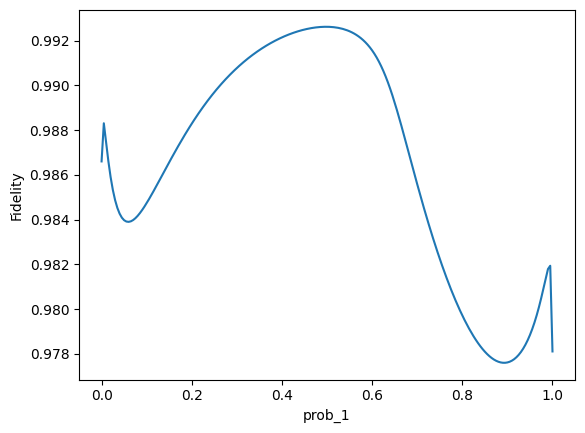

[np.float64(0.9866032206056103), np.float64(0.9883081423503843), np.float64(0.9874622725778739), np.float64(0.9866233040519261), np.float64(0.9859089101060174), np.float64(0.9853297159523235), np.float64(0.9848742003148911), np.float64(0.984526198659689), np.float64(0.9842697632291402), np.float64(0.9840906648725041), np.float64(0.9839765493199895), np.float64(0.9839169554512199), np.float64(0.9839030223511317), np.float64(0.9839272733010475), np.float64(0.9839834353000014), np.float64(0.9840661896968265), np.float64(0.9841710207326478), np.float64(0.984294152304767), np.float64(0.9844323343594972), np.float64(0.9845828136504582), np.float64(0.9847432249564809), np.float64(0.9849115614790687), np.float64(0.9850861076684421), np.float64(0.9852653724349348), np.float64(0.9854481172207938), np.float64(0.9856332157479452), np.float64(0.9858197722176093), np.float64(0.9860069763229388), np.float64(0.9861941331602714), np.float64(0.9863806571345826), np.float64(0.9865660468400756), np.float6

In [8]:

rank = 2

print("\n\n prob_1 * AA + prob_2 * RR  \n")


n_hh =  0.1 / 177.8
n_hv_1 = 4.1 / 177.8
n_hv_2 = 5.45 / 45.9
n_vv = 0.65 / 45.9

sigma1_1 = 12.45 - 39.05 * n_hh
sigma2_1 = (134.2 - 12.45 * n_hv_1 - 39.05 * n_hv_2)/2
sigma3_1 = 39.05 - 12.45 * n_vv

teor_state_1 = tomography.density(tomography.aa)

freq_1 = array([
12.45 - 39.05 * n_hh, 134.2 - 12.45 * n_hv_1 - 39.05 * n_hv_2,	39.05 - 12.45 * n_vv,
3.2 - 99.5 * n_hh, 108.05 - 3.2 * n_hv_1 - 99.5 * n_hv_2, 99.5 - 3.2 * n_vv,
26.4 - 13.8 * n_hh, 114.5 - 26.4 * n_hv_1 - 13.8 * n_hv_2, 13.8 - 26.4 * n_vv,
4.2 - 78.9 * n_hh, 143.6 - 4.2  * n_hv_1 - 78.9 * n_hv_2, 78.9 - 4.2  * n_vv,
29.7 - 6.4 * n_hh, 116.75 - 29.7 * n_hv_1 - 6.4 * n_hv_2, 6.4 - 29.7 * n_vv
])

n_hh = 0 / 154
n_hv_1 = 4 / 154
n_hv_2 = 7.45 / 42.2
n_vv = 0.4 / 42.2

sigma1_2 = 9.75 - 29.55 * n_hh
sigma2_2 = (131.7 - 9.75 * n_hv_1 - 29.55 * n_hv_2)/2
sigma3_2 = 29.55 - 9.75 * n_vv

teor_state_2 = tomography.density(tomography.rr)

freq_2 = array([
9.75 - 29.55 * n_hh, 131.7 - 9.75 * n_hv_1 - 29.55 * n_hv_2,	29.55 - 9.75 * n_vv,
30.2 - 4.35 * n_hh, 51.1 - 30.2 * n_hv_1 - 4.35 * n_hv_2, 4.35 - 30.2 * n_vv,
28.1 - 2.25 * n_hh, 75.05 - 28.1 * n_hv_1 - 2.25 * n_hv_2, 2.25 - 28.1 * n_vv,
0.4 - 125.9 * n_hh, 43.2 - 0.4 * n_hv_1 - 125.9  * 0, 125.9  - 0.4  * n_vv,
1.45 - 94.35 * n_hh, 94.8 - 1.45 * n_hv_1 - 94.35 * n_hv_2, 94.35 - 1.45 * n_vv
])

list_prob_1 = linspace(0.0, 1.0, 201)
list_fid = [0] * len(list_prob_1)

for i, prob_1 in enumerate(list_prob_1):

    prob_2 = 1.0 - prob_1

    teor_state = prob_1 * teor_state_1 + prob_2 * teor_state_2
    freq = prob_1 * freq_1 + prob_2 * freq_2
    sigma1 = prob_1 * sigma1_1 + prob_2 * sigma1_2
    sigma2 = prob_1 * sigma2_1 + prob_2 * sigma2_2
    sigma3 = prob_1 * sigma3_1 + prob_2 * sigma3_2
    # freq[::3] = freq[::3] / sigma1
    # freq[1::3] = freq[1::3] / sigma2
    # freq[2::3] = freq[2::3] / sigma3

    tomography.experiment(freq, teor_state, sigma1, sigma2, sigma3, rank, visible=False)
    list_fid[i] = abs(tomography.Fidelity(tomography.matrix_finish, tomography.start_density))

plt.plot(list_prob_1, list_fid)
plt.xlabel("prob_1")
plt.ylabel("Fidelity")
plt.show()
print(list_fid)

Переношу экспериментальные данные и собираю в словарь

In [83]:
dict_k_l_4 = dict()
dict_sigma_l_4 = dict()
protocol = [Gl_4(0), Gl_4(pi / 8), Gl_4(3 * pi / 8), Gl_4(5 * pi / 8), Gl_4(7 * pi / 8)]
Start_protocol = tomography_pol_qutrit(protocol)
rank = 1
print("\n\n HH  \n")
# # 20 повторения по 10с при HWP_p под 0
# Noise
# 1.2 3.15 233.6
# 72.7 5.35 1.15
# Калибровка      10.7 100.1 69.15
n_hh = 1.2 / 233.6
n_hv_1 = 3.15 / 233.6
n_hv_2 = 5.35 / 72.7
n_vv = 1.15 / 72.7

dict_sigma_l_4["HH"] = array([10.7 - 69.15 * n_hh, (100.1 - 10.7 * n_hv_1 - 69.15 * n_hv_2)/2, 69.15 - 10.7 * n_vv])
dict_k_l_4["HH"] = array([
72.7 - 1.15 * n_hh, 5.35 - 5.35,	1.15 - 72. * n_vv,
44.6 - 20.95 * n_hh, 58.1 - 44.6 * n_hv_1 - 20.95 * n_hv_2, 20.95 - 44.6 * n_vv,
34.55 - 12.95 * n_hh, 94.55 - 34.55 * n_hv_1 - 12.95 * n_hv_2, 12.95 - 34.55 * n_vv,
39.9 - 10.7 * n_hh, 78.3 - 39.9 * n_hv_1 - 10.7 * n_hv_2, 10.7 - 39.9 * n_vv,
37.35 - 22.3 * n_hh, 73.65 - 37.35 * n_hv_1 - 22.3 * n_hv_2, 22.3 - 37.35 * n_vv
])

print("\n\n VV  \n")
# # 20 повторения по 10с при HWP_p под 0
# Noise
# 0.45 1.65 186.9
# 67.85 4.6 1.5
# Калибровка      21.55 92.1 45.35
n_hh = 0.45 / 186.59
n_hv_1 = 1.9 / 186.9
n_hv_2 = 4.6 / 67.85
n_vv = 1.5 / 67.85

dict_sigma_l_4["VV"] = array([21.55 - 45.35 * n_hh, (92.1 - 21.55 * n_hv_1 - 45.35 * n_hv_2)/2, 45.35 - 21.55 * n_vv])

dict_k_l_4["VV"] = array([
0.45 - 186.9 * n_hh, 1.65 - 1.65,	186.9 - 0.45 * n_vv,
3.95 - 108.6 * n_hh, 88.9 - 3.95 * n_hv_1 - 108.6 * n_hv_2, 108.6 - 3.95 * n_vv,
5.25 - 103.55 * n_hh, 91.95 - 5.25 * n_hv_1 - 103.55 * n_hv_2, 103.55 - 5.25 * n_vv,
3.1 - 108.95 * n_hh, 89.45 - 3.1 * n_hv_1 - 108.95 * n_hv_2, 108.95 - 3.1 * n_vv,
6.2 - 107.1 * n_hh, 86.35 - 6.2 * n_hv_1 - 107.1 * n_hv_2, 107.1 - 6.2 * n_vv
])

print("\n\n AA  \n")
# # 20 повторения по 10с при HWP_p под 0 HWP_B1 под 24.5
# Noise
# 0.1 4.1 177.8
# 45.9 15.45 0.65

n_hh =  0.1 / 177.8
n_hv_1 = 4.1 / 177.8
n_hv_2 = 5.45 / 45.9
n_vv = 0.65 / 45.9

dict_sigma_l_4["AA"] = array([12.45 - 39.05 * n_hh, (134.2 - 12.45 * n_hv_1 - 39.05 * n_hv_2)/2, 39.05 - 12.45 * n_vv])

dict_k_l_4["AA"] = array([
12.45 - 39.05 * n_hh, 134.2 - 12.45 * n_hv_1 - 39.05 * n_hv_2,	39.05 - 12.45 * n_vv,
3.2 - 99.5 * n_hh, 108.05 - 3.2 * n_hv_1 - 99.5 * n_hv_2, 99.5 - 3.2 * n_vv,
26.4 - 13.8 * n_hh, 114.5 - 26.4 * n_hv_1 - 13.8 * n_hv_2, 13.8 - 26.4 * n_vv,
4.2 - 78.9 * n_hh, 143.6 - 4.2  * n_hv_1 - 78.9 * n_hv_2, 78.9 - 4.2  * n_vv,
29.7 - 6.4 * n_hh, 116.75 - 29.7 * n_hv_1 - 6.4 * n_hv_2, 6.4 - 29.7 * n_vv
])

print("\n\n DD  \n")
# # 20 повторения по 10с при HWP_p под 0
# Noise
# 0.5 4.05 181.35
# 71.7 3.25 1.1

n_hh = 0.5 / 181.35
n_hv_1 = 4.05 / 181.35
n_hv_2 = 3.25 / 71.7
n_vv = 1.1 / 71.7

dict_sigma_l_4["DD"] = array([18.5 - 43.65 * n_hh, (152 - 18.5 * n_hv_1 - 43.65 * n_hv_2)/2, 43.65 - 18.5 * n_vv])

dict_k_l_4["DD"] = array([
18.5 - 43.65 * n_hh, 152 - 18.5 * n_hv_1 - 43.65 * n_hv_2,	43.65 - 18.5 * n_vv,
41.35 - 16.1 * n_hh, 90.1 - 41.35 * n_hv_1 - 16.1 * n_hv_2, 16.1 - 41.35 * n_vv,
5.4 - 115.3 * n_hh, 83.45 - 5.4 * n_hv_1 - 115.3 * n_hv_2, 115.3 - 5.4 * n_vv,
44.15 - 8.55 * n_hh, 83.65 - 44.15 * n_hv_1 - 8.55 * n_hv_2, 8.55 - 44.15 * n_vv,
7.4 - 94.65 * n_hh, 103.65 - 7.4 * n_hv_1 - 94.65 * n_hv_2, 94.65 - 7.4 * n_vv
])

print("\n\n LL \n")
# # 20 повторения по 10с при HWP_p под 0 HWP_B1 под 24.5
# Noise
# 0 4.1 169.5
# 44.75 15.45 0.55

n_hh =  0 / 169.5
n_hv_1 = 5 / 169.5
n_hv_2 = 6.3 / 44.75
n_vv = 0.55 / 44.75

dict_sigma_l_4["LL"] = array([10.75 - 41.45 * n_hh, (142.85 - 10.75 * n_hv_1 - 41.45 * n_hv_2)/2, 41.45 - 10.75 * n_vv])

dict_k_l_4["LL"] = array([
10.75 - 41.45 * n_hh, 142.85 - 10.75 * n_hv_1 - 41.45 * n_hv_2,	41.45 - 10.75 * n_vv,
0.35 - 129.15 * n_hh, 55.45 - 0.35 * n_hv_1 - 129.15 * n_hv_2, 129.15 - 0.35 * n_vv,
1.45 - 113.8 * n_hh, 81.1 - 1.45 * n_hv_1 - 113.8 * n_hv_2, 113.8 - 1.45 * n_vv,
34.3 - 1.45 * n_hh, 57.3 - 34.3  * n_hv_1 - 1.45 * n_hv_2, 1.45 - 34.3  * n_vv,
27.8 - 9.2 * n_hh, 90.75 - 27.8 * n_hv_1 - 9.2 * n_hv_2, 9.2 - 27.8 * n_vv
])

print("\n\n RR \n")
# # 20 повторения по 10с при HWP_p под 0 HWP_B1 под 24.5
# Noise
# 0.05 9.65 154
# 42.2 12.75 0.4

n_hh = 0 / 154
n_hv_1 = 4 / 154
n_hv_2 = 7.45 / 42.2
n_vv = 0.4 / 42.2

dict_sigma_l_4["RR"] = array([9.75 - 29.55 * n_hh, (131.7 - 9.75 * n_hv_1 - 29.55 * n_hv_2)/2, 29.55 - 9.75 * n_vv])

dict_k_l_4["RR"] = array([
9.75 - 29.55 * n_hh, 131.7 - 9.75 * n_hv_1 - 29.55 * n_hv_2,	29.55 - 9.75 * n_vv,
30.2 - 4.35 * n_hh, 51.1 - 30.2 * n_hv_1 - 4.35 * n_hv_2, 4.35 - 30.2 * n_vv,
28.1 - 2.25 * n_hh, 75.05 - 28.1 * n_hv_1 - 2.25 * n_hv_2, 2.25 - 28.1 * n_vv,
0.4 - 125.9 * n_hh, 43.2 - 0.4 * n_hv_1 - 125.9  * 0, 125.9  - 0.4  * n_vv,
1.45 - 94.35 * n_hh, 94.8 - 1.45 * n_hv_1 - 94.35 * n_hv_2, 94.35 - 1.45 * n_vv
])


print("\n\n VV + iHH \n")
# # 20 повторения по 10с при HWP_p под 0 HWP_B1 под 24.5
# Noise
# 39.05 5.4 30.9
# 0.55 170.7 1.5

# Калибровка
# 22.85 87.75 26.8
n_hh = 0.55 / 225.45
n_hv = 5.4 / (39.05 + 30.9)
n_vv = 1.5 / 225.45

dict_sigma_l_4["VV + iHH"] = array([22.85 - 87.75 * n_hh, (87.75 - (22.85 + 26.8) * n_hv)/2, 26.8 - 87.75 * n_vv])

dict_k_l_4["VV + iHH"] = array([
39.05 - 5.4 * n_hh, 5.4 - (39.05 + 30.9) * n_hv,	30.9 - 5.4 * n_vv,
13.7 - 150.9 * n_hh,  150.9 - (13.7 + 11.9) * n_hv,	11.9 - 150.9 * n_vv,
36.85 - 6.1 * n_hh, 6.1- (36.85 + 33.95) * n_hv, 33.95 - 6.1 * n_vv,
37 - 5.9 * n_hh,  5.9 - (37 + 36.85) * n_hv,  36.85  - 5.9 * n_vv,
10.65 - 165.6 * n_hh,  165.6 - (10.65 + 12.5) * n_hv,   12.5 - 165.6 * n_vv
])

print("\n\n DD + iAA \n")
# # 20 повторения по 10с при HWP_p под 0
# Noise
# 29.65 3.1 80.7
# 2.35 183.2 3.4

n_hh = 2.35 / 183.2
n_hv = 7.5 / (29.65 + 80.7)
n_vv = 3.4 / 183.2

dict_sigma_l_4["DD + iAA"] = array([19.1 - 119.35 * n_hh, (119.35 - (19.1 + 61.75) * n_hv)/2, 61.75 - 119.35 * n_vv])

dict_k_l_4["DD + iAA"] = array([
19.1 - 119.35 * n_hh, 119.35 - (19.1 + 61.75) * n_hv,	61.75 - 119.35 * n_vv,
8.55 - 153.75 * n_hh, 153.75 - (8.55 + 29.95) * n_hv,	29.95 - 153.75 * n_vv,
14.6 - 131.55 * n_vv, 131.55 - (14.6 + 30.2) * n_hv, 30.2 - 131.55 * n_hh,
28.15 - 7.25 * n_hh, 7.25 - (28.15 + 94) * n_hv, 94 - 7.25 * n_vv,
34 - 13 * n_hh, 13 - (34 + 77.8) * n_hv, 77.8 - 13 * n_vv
])

print("\n\n RR - iLL \n")
# # 20 повторения по 10с при HWP_p под 0 HWP_B1 под 24.5
# Noise
# 42.05 7.7 33.09
# 1.15 225.75 2.75

n_hh = 1.15 / 225.75
n_hv = 7.7 / (33.09 + 42.05)
n_vv = 2.75 / 225.75


dict_sigma_l_4["RR - iLL"] = array([18.3 - 171.15 * n_hh, (171.15 - (18.3 + 13.7) * n_hv)/2, 13.7 - 171.15 * n_vv])

dict_k_l_4["RR - iLL"] = array([
18.3 - 171.15 * n_hh,   171.15 - (18.3 + 13.7) * n_hv,	13.7 - 171.15 * n_vv,
18.3 - 151.45 * n_hh,  151.45 - (18.3 + 13.75) * n_hv,	13.75 - 151.45 * n_vv,
42.05 - 7.7 * n_hh, 7.7- (33.09 + 42.05) * n_hv,    33.09 - 7.7 * n_vv,
17.55 - 150.4 * n_hh,  150.4 - (17.55 + 21.1) * n_hv,  21.1  - 150.4 * n_vv,
42 - 5.85 * n_hh,  5.85 - 5.85,   42.1 - 42 * n_vv
])



 HH  



 VV  



 AA  



 DD  



 LL 



 RR 



 VV + iHH 



 DD + iAA 



 RR - iLL 



In [17]:
from Qutrit import*
assert len(dict_k_l_4) == 9 and len(dict_sigma_l_4) == 9
name_state = ["HH", "VV", "AA", "DD", "LL", "RR", "VV + iHH", "DD + iAA", "RR - iLL"]
dict_pure_state = dict()
dict_pure_state["HH"] = hh @ hh.T.conj()
dict_pure_state["VV"] = vv @ vv.T.conj()
dict_pure_state["AA"] = aa @ aa.T.conj()
dict_pure_state["DD"] = dd @ dd.T.conj()
dict_pure_state["RR"] = rr @ rr.T.conj()
dict_pure_state["LL"] = ll @ ll.T.conj()
dict_pure_state["VV + iHH"] = (vv + 1j * hh) @ (vv + 1j * hh).T.conj()
dict_pure_state["VV + iHH"] /= trace(dict_pure_state["VV + iHH"])
dict_pure_state["DD + iAA"] = (dd + 1j * aa) @ (dd + 1j * aa).T.conj()
dict_pure_state["DD + iAA"] /= trace(dict_pure_state["DD + iAA"])
dict_pure_state["RR - iLL"] = (rr - 1j * ll) @ (rr - 1j * ll).T.conj()
dict_pure_state["RR - iLL"] /= trace(dict_pure_state["RR - iLL"])


def fidelity_mix_state(rank, prob, freq, pure_state, sigma):
    protocol = [Gl_4(0), Gl_4(pi / 8), Gl_4(3 * pi / 8), Gl_4(5 * pi / 8), Gl_4(7 * pi / 8)]
    tomography = tomography_pol_qutrit(protocol)

    teor_state = np.tensordot(prob, pure_state, axes=([0], [0]))
    freq = np.tensordot(prob, freq, axes=([0], [0]))
    sigma1 = float(np.tensordot(prob, sigma[0], axes=([0], [0])))
    sigma2 = float(np.tensordot(prob, sigma[1], axes=([0], [0])))
    sigma3 = float(np.tensordot(prob, sigma[2], axes=([0], [0])))
    # freq[::3] = freq[::3] / sigma1
    # freq[1::3] = freq[1::3] / sigma2
    # freq[2::3] = freq[2::3] / sigma3

    tomography.experiment(freq, teor_state, sigma1, sigma2, sigma3, rank, visible=False)
    fid = abs(tomography.Fidelity(tomography.matrix_finish, tomography.start_density))
    return fid

100%|██████████| 10000/10000 [06:38<00:00, 25.09it/s]


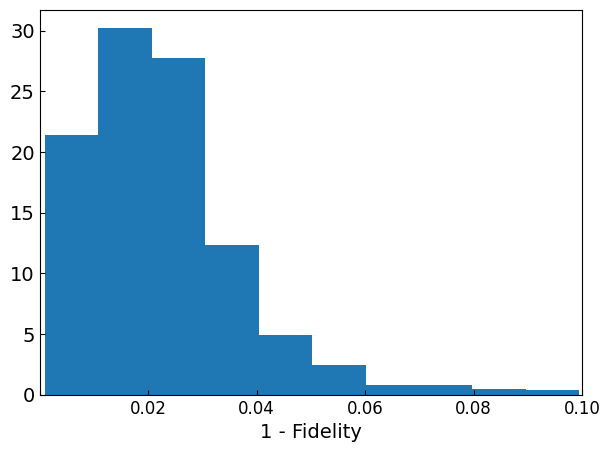

In [87]:
import random
from tqdm import tqdm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

rank = 2
N_shots = 10000
hist_fid = [0] * N_shots
plt.rcParams.update({"font.family": "DejaVu Sans",
                    "axes.titlesize": 14,
                     "axes.labelsize":14})

for i in tqdm(range(N_shots)):
    name_1, name_2 = name_state[random.randint(0, 8)], name_state[random.randint(0, 8)]
    pure_state = np.array([dict_pure_state[name_1], dict_pure_state[name_2]])

    prob1 = random.uniform(0, 1)
    prob = np.array([prob1, 1 - prob1]) 
    freq = np.array([dict_k_l_4[name_1], dict_k_l_4[name_2]])
    sigma = [np.array([dict_sigma_l_4[name_1][0], dict_sigma_l_4[name_2][0]]), np.array([dict_sigma_l_4[name_1][1], dict_sigma_l_4[name_2][1]]), np.array([dict_sigma_l_4[name_1][2], dict_sigma_l_4[name_2][2]])]

    hist_fid[i] = 1 - (fidelity_mix_state(rank, prob, freq, pure_state, sigma))

hist_fid_2 = array(hist_fid)
fig, ax = plt.subplots(figsize=(7, 5))

# ax.hist(hist_fid_2, density=True)
mask = (hist_fid_2 >= 0) & (hist_fid_2 <= 1e-1)
limited_data = hist_fid_2[mask]
# ax.tick_params(axis='both', direction='in')

# axins = inset_axes(ax, width="40%", height="40%", loc='upper right', borderpad=2)
# ax.set_xlabel("1 - Fidelity")
# Рисуем гистограмму в врезке
ax.hist(limited_data, density=True)
ax.set_xlim(0, 1e-1)
ax.set_xlabel("1 - Fidelity")
ax.tick_params(axis='both', direction='in')
ax.xaxis.get_major_ticks()[0].label1.set_visible(False)
plt.show()

100%|██████████| 10000/10000 [09:18<00:00, 17.89it/s]


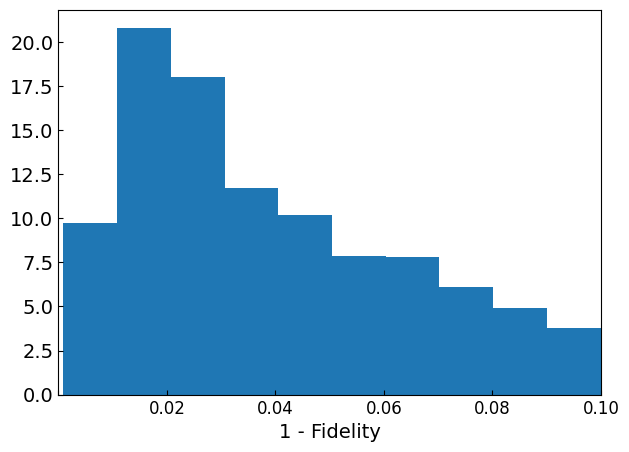

In [88]:
rank = 3
N_shots = 10000
hist_fid = [0] * N_shots
plt.rcParams.update({"font.family": "DejaVu Sans",
                    "axes.titlesize": 14,
                     "axes.labelsize":14})

for i in tqdm(range(N_shots)):
    
    name_1, name_2, name_3 = name_state[random.randint(0, 8)], name_state[random.randint(0, 8)], name_state[random.randint(0, 8)]
    pure_state = np.array([dict_pure_state[name_1], dict_pure_state[name_2], dict_pure_state[name_3]])

    prob = np.array([random.uniform(0, 1) for _ in range(3)])
    prob /= np.sum(prob)
    freq = np.array([dict_k_l_4[name_1], dict_k_l_4[name_2], dict_k_l_4[name_3]])
    sigma = [np.array([dict_sigma_l_4[name_1][0], dict_sigma_l_4[name_2][0], dict_sigma_l_4[name_3][0]]), np.array([dict_sigma_l_4[name_1][1], dict_sigma_l_4[name_2][1], dict_sigma_l_4[name_3][1]]), np.array([dict_sigma_l_4[name_1][2], dict_sigma_l_4[name_2][2], dict_sigma_l_4[name_2][2]])]

    hist_fid[i] = 1 - (fidelity_mix_state(rank, prob, freq, pure_state, sigma))

hist_fid_3 = array(hist_fid)
fig, ax = plt.subplots(figsize=(7, 5))
# ax.tick_params(axis='both', direction='in')
# ax.hist(hist_fid_3, density=True)
mask = (hist_fid_3 >= 0) & (hist_fid_3 <= 1e-1)
limited_data = hist_fid_3[mask]
# axins = inset_axes(ax, width="40%", height="40%", loc='upper right', borderpad=2)
# ax.set_xlabel("1 - Fidelity")

# Рисуем гистограмму в врезке
ax.hist(limited_data, density=True)
ax.set_xlim(0, 1e-1)
ax.set_xlabel("1 - Fidelity")
ax.tick_params(axis='both', direction='in')
ax.xaxis.get_major_ticks()[0].label1.set_visible(False)
plt.show()

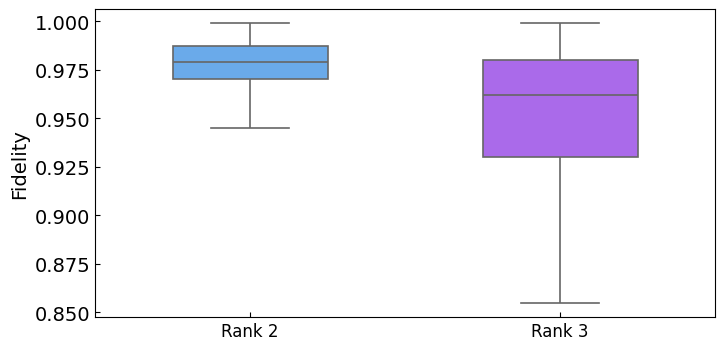

In [89]:
import seaborn as sns
import pandas as pd


df = pd.DataFrame({
    'value': np.concatenate([1 - np.array(hist_fid_2), 1 - np.array(hist_fid_3)]),
    'group': ['Rank 2'] * len(hist_fid_2) + ['Rank 3'] * len(hist_fid_3)
})

plt.rcParams.update({"font.family": "DejaVu Sans",
                    "axes.titlesize": 14,
                     "axes.labelsize":14})
# Строим boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x='group', y='value', hue='group', data=df, showfliers=False,
            palette='cool', width=0.5, fliersize=3, linewidth=1.2)
plt.rcParams.update({'font.size': 14})
plt.tick_params(axis='both', direction='in')
# plt.title('Сравнение распределений (sns.boxplot)')
plt.xlabel('')
plt.ylabel('Fidelity')
plt.show()